# **Importing all essential libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("AEP_hourly.csv")
df.sample(6)

,Datetime,AEP_MW
60256,2011-05-17 08:00:00,15299.0
73198,2013-11-25 18:00:00,18104.0
15599,2006-06-21 04:00:00,12894.0
52961,2010-03-17 07:00:00,16454.0
39956,2009-09-10 07:00:00,13980.0
18367,2006-02-26 13:00:00,16115.0


### **Dataset & EDA Objective**
This dataset contains hourly electricity consumption data for the AEP power system over multiple years. 

The Objective of this EDA was To analyze historical hourly energy consumption data and identify key temporal patterns, seasonal trends, peak demand periods, and consumption behavior that can support better energy planning and demand forecasting.


### Dataset Overview :

In [3]:
df.shape

(121273, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [6]:
df.isnull().sum()

Datetime    0
AEP_MW      0
dtype: int64

In [5]:
df.describe(include= "all")

,Datetime,AEP_MW
count,121273,121273.000000
unique,121269,NaN
top,2014-11-02 02:00:00,NaN
freq,2,NaN
mean,NaN,15499.513717
std,NaN,2591.399065
min,NaN,9581.000000
25%,NaN,13630.000000
50%,NaN,15310.000000
75%,NaN,17200.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.tail(10)

,Datetime,AEP_MW
121263,2018-01-01 15:00:00,18619.0
121264,2018-01-01 16:00:00,18691.0
121265,2018-01-01 17:00:00,19109.0
121266,2018-01-01 18:00:00,20279.0
121267,2018-01-01 19:00:00,20925.0
121268,2018-01-01 20:00:00,21089.0
121269,2018-01-01 21:00:00,20999.0
121270,2018-01-01 22:00:00,20820.0
121271,2018-01-01 23:00:00,20415.0
121272,2018-01-02 00:00:00,19993.0


## Time-based Feature Engineering

In [4]:
df.dtypes

Datetime     object
AEP_MW      float64
dtype: object

In [5]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

In [6]:
df['Datetime'].dtype

dtype('<M8[ns]')

In [7]:
# Year
df['Year'] = df['Datetime'].dt.year

# Month Number
df['Month'] = df['Datetime'].dt.month

# Day
df['Day'] = df['Datetime'].dt.day

# Hour
df['Hour'] = df['Datetime'].dt.hour

# Day Name
df['Day_Name'] = df['Datetime'].dt.day_name()

# Day_type
df['Day_Type'] = df['Day_Name'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday']
    else 'Weekday')

## **Univatiate Analysis** :

### Enery consumption 

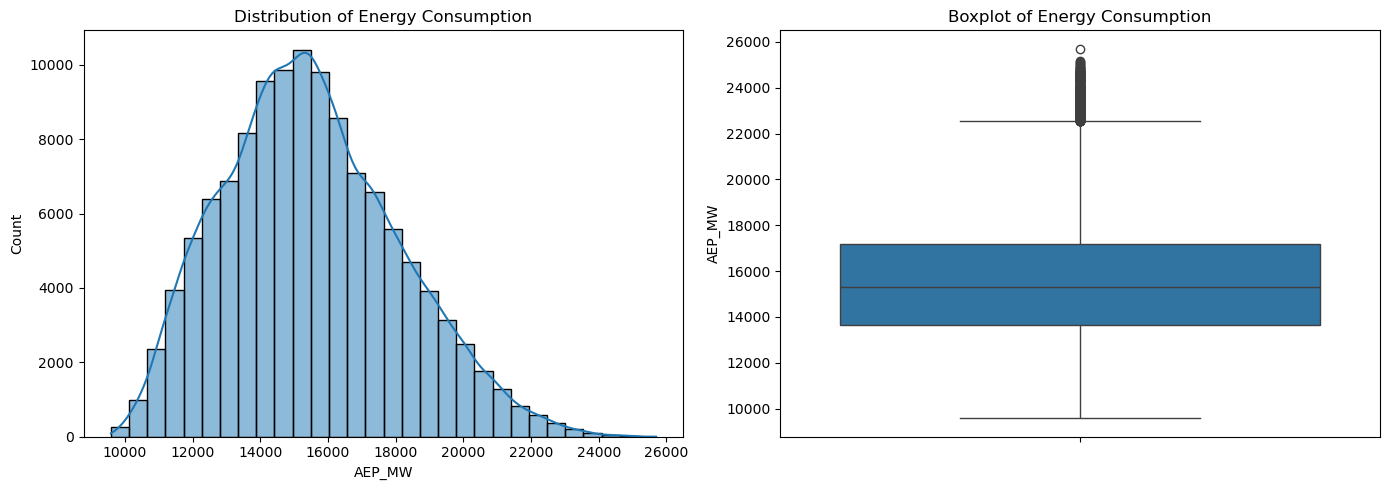

In [12]:
fig, ax = plt.subplots(
    1, 2,
    figsize=(14,5))

# Histogram
sns.histplot(
    df['AEP_MW'],
    bins=30,
    kde=True,
    ax=ax[0])

ax[0].set_title("Distribution of Energy Consumption")
ax[0].set_xlabel("AEP_MW")

# Boxplot
sns.boxplot(
    y=df['AEP_MW'],
    ax=ax[1])
ax[1].set_title("Boxplot of Energy Consumption")
ax[1].set_ylabel("AEP_MW")
plt.tight_layout()
plt.show()

- Electricity demand is generally stable and predictable most of the time.
- The few extreme high-demand observations likely correspond to heat waves, cold snaps, holidays, or special events when electricity usage surges.
- The boxplot shows several high-end outliers above 22,500 MW, indicating some unusually high demand periods.
- Energy consumption is mostly stable, but occasional demand spikes require utilities to keep reserve power available to ensure grid reliability.

In [9]:
df['AEP_MW'].skew()
# Normal ≈ 0 

np.float64(0.3789980419049807)

In [20]:
df["Month"].describe()

count    121273.000000
mean          6.500309
std           3.461454
min           1.000000
25%           4.000000
50%           6.000000
75%          10.000000
max          12.000000
Name: Month, dtype: float64

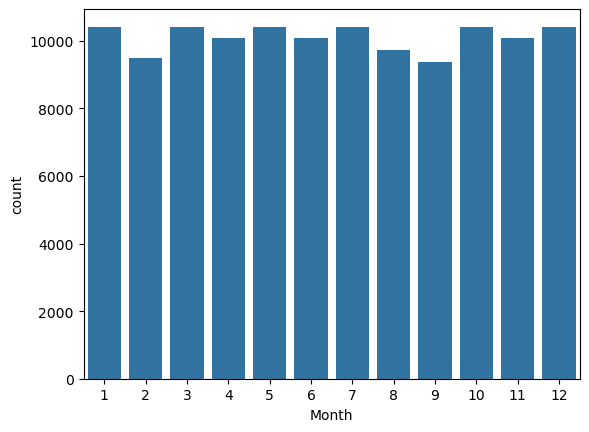

In [11]:
sns.countplot(data=df,x='Month')plt.show()

- All 12 months have almost the same number of records. No month is heavily overrepresented or underrepresented.
- The dataset is well-balanced across the entire year. Slight differences are due to months having different numbers of days (28, 30, or 31).

###  **Bivariate Analysis** : 

### Hourly Average Energy Consumption 

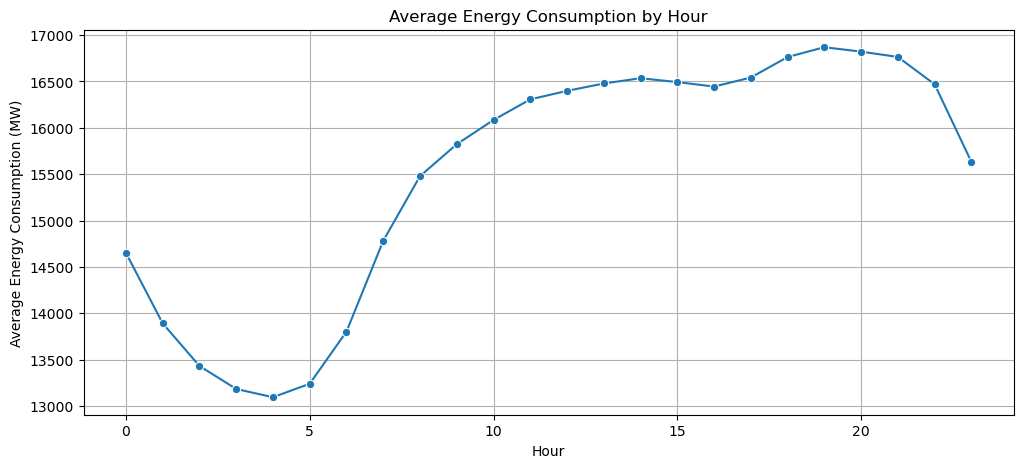

In [20]:
hourly = df.groupby('Hour')['AEP_MW'].mean()
plt.figure(figsize=(12,5))

sns.lineplot(
    x=hourly.index,
    y=hourly.values,
    marker='o')

plt.title('Average Energy Consumption by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Energy Consumption (MW)')

plt.grid(True)

plt.show()

- Electricity use is lowest during the early morning hours (around 3–5 AM).
- After morning, There is a sharp increase in electricity use between 6 AM and 8 AM.
- Electricity use stays high during the afternoon and evening, reaching its highest level around 18- 20 PM.
- Power companies should focus on supplying extra electricity during evening hours because that is when demand is highest

## Weekday vs Weekend

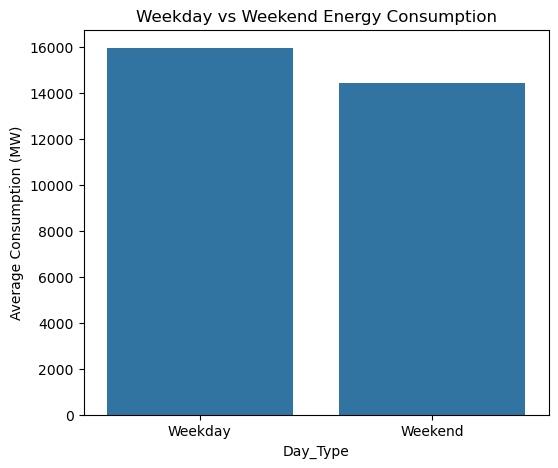

In [13]:
day_type = df.groupby('Day_Type')['AEP_MW'].mean()

plt.figure(figsize=(6,5))

sns.barplot(
    x=day_type.index,
    y=day_type.values)

plt.title('Weekday vs Weekend Energy Consumption')
plt.ylabel('Average Consumption (MW)')

plt.show()

- Electricity use is higher on weekdays than on weekends.This means the type of day (working day or holiday/weekend) affects how much electricity people use
- During weekdays, offices, factories, schools, and businesses use a lot of electricity..
- There is a clear drop in electricity use on weekend. On weekends, many workplaces are closed, so total electricity demand falls.
- Weekday consumption is higher due to industrial and commercial activity.

## Month vs Energy Consumption 

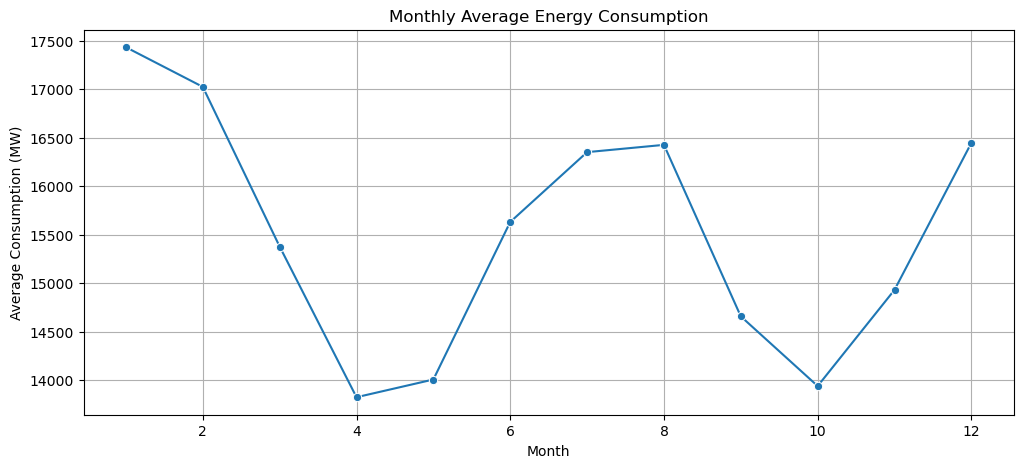

In [21]:
monthly = df.groupby('Month')['AEP_MW'].mean().reset_index()

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly,
    x='Month',
    y='AEP_MW',
    marker='o')
plt.title('Monthly Average Energy Consumption')
plt.xlabel('Month')
plt.ylabel('Average Consumption (MW)')
plt.grid(True)

plt.show()

- There are two high-demand periods instead of just one.
- The first peak happens in winter (January–February). In winter, people use more electricity for heating, lighting, and indoor activities.
- The second peak happens in summer (June–August). In summer, electricity use rises because of air conditioners and cooling systems.
- The lowest electricity use is seen around April and October. During spring and autumn, weather is usually comfortable, so less heating or cooling is needed.

## Year vs Energy Consumption

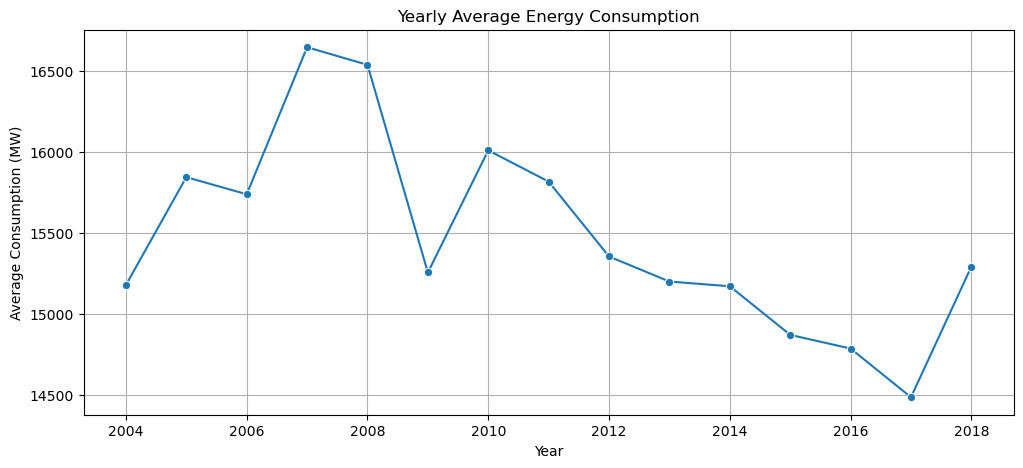

In [24]:
yearly = df.groupby('Year')['AEP_MW'].mean().reset_index()

plt.figure(figsize=(12,5))

sns.lineplot(
    data=yearly,
    x='Year',
    y='AEP_MW',
    marker='o'
)

plt.title('Yearly Average Energy Consumption')
plt.xlabel('Year')
plt.ylabel('Average Consumption (MW)')
plt.grid(True)

plt.show()

- The highest electricity use appears around 2007–2008.
- There is a noticeable drop between 2008 and 2009. and From 2011 onward, electricity use slowly decreases for several years.
- Changes in electricity use over the years can happen because of population changes, economic activity, weather conditions, or energy-efficient technologies.The long-term decrease suggests people and businesses may have started using electricity more efficiently.
- The jump from 2017 to 2018 , it shows that demand can rise again when conditions change.
- This shows that people's electricity needs can change over time because of technology, weather, and economic activity.

### Energy Consumption:  ***2005 VS 2017***

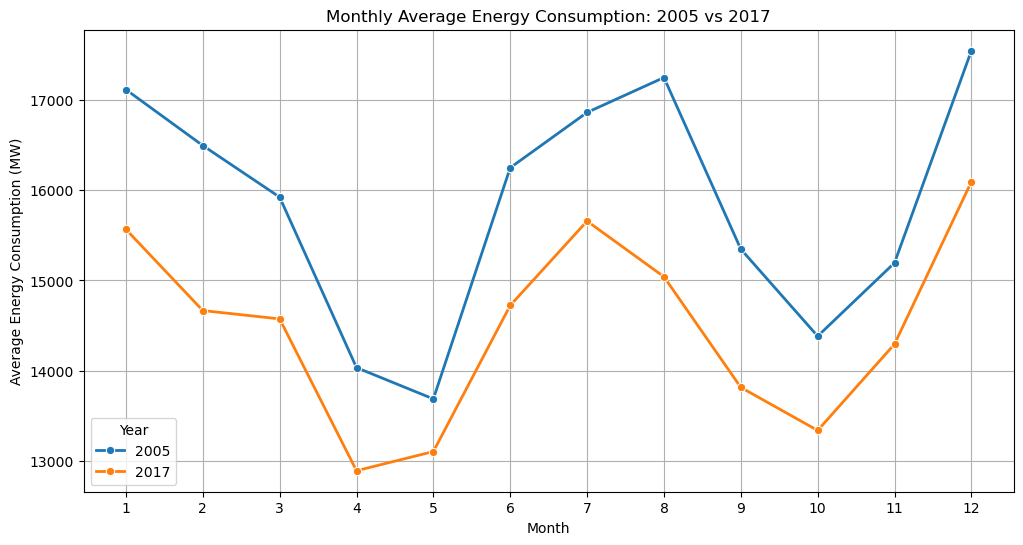

In [15]:
compare_years = df[df['Year'].isin([2005, 2017])]
monthly_compare = (compare_years
    .groupby(['Year', 'Month'])['AEP_MW'].mean().reset_index())
plt.figure(figsize=(12,6))
sns.lineplot(
    data=monthly_compare, x='Month', y='AEP_MW', hue='Year',
    marker='o', linewidth=2, palette=['#1f77b4', '#ff7f0e'])
plt.title('Monthly Average Energy Consumption: 2005 vs 2017')
plt.xlabel('Month')
plt.ylabel('Average Energy Consumption (MW)')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

- Both years follow a similar pattern: electricity use is higher in winter and summer and lower during spring.The weather affects electricity use in the same way in both years.
- Even though the overall levels are different, the shape of the two lines is very similar.
- people used less electricity overall in 2017 compared to 2005.
- The lower demand in 2017 may suggest better energy efficiency, improved appliances, or changes in electricity usage habits.

In [51]:
df[df['Year'] == 2018]['Month'].unique()

array([1, 2, 3, 4, 5, 6, 7, 8], dtype=int32)

In [55]:
df['Datetime'].min(), df['Datetime'].max()

(Timestamp('2004-10-01 01:00:00'), Timestamp('2018-08-03 00:00:00'))

## Multivariate Analysis :

### 1. Hourly Energy Consumption: Weekday vs Weekend

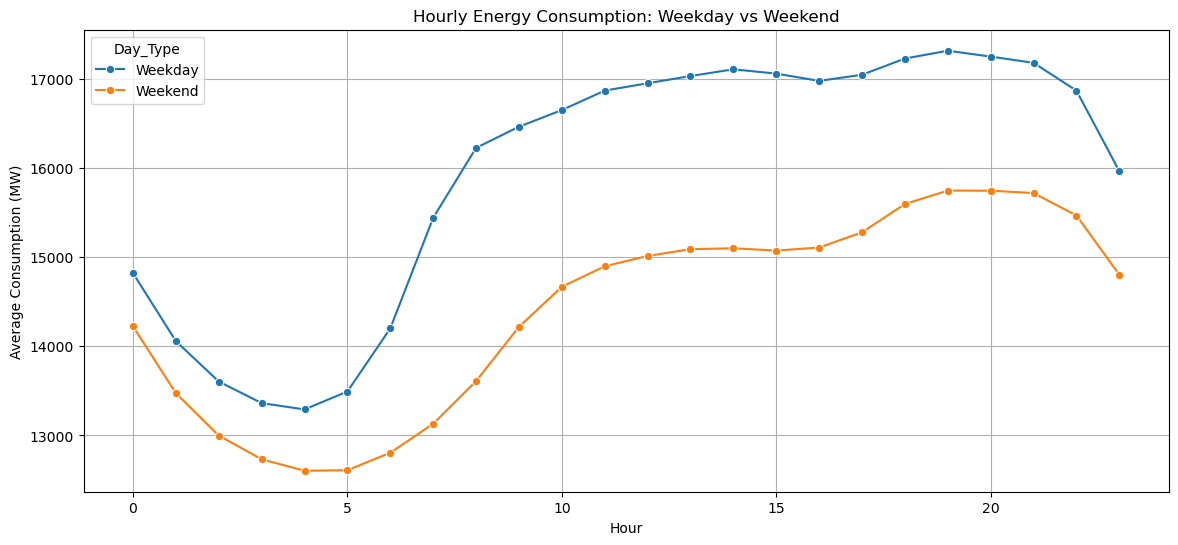

In [57]:
hour_daytype = df.groupby(
    ['Hour', 'Day_Type']
)['AEP_MW'].mean().reset_index()

plt.figure(figsize=(14,6))

sns.lineplot(
    data=hour_daytype,
    x='Hour',
    y='AEP_MW',
    hue='Day_Type',
    marker='o'
)

plt.title('Hourly Energy Consumption: Weekday vs Weekend')
plt.ylabel('Average Consumption (MW)')
plt.grid(True)

plt.show()

- Weekdays follow the same daily pattern as weekends: low in the early morning, rising after sunrise, and peaking in the evening, but at a much higher level.

### 2. Year × Month Heatmap

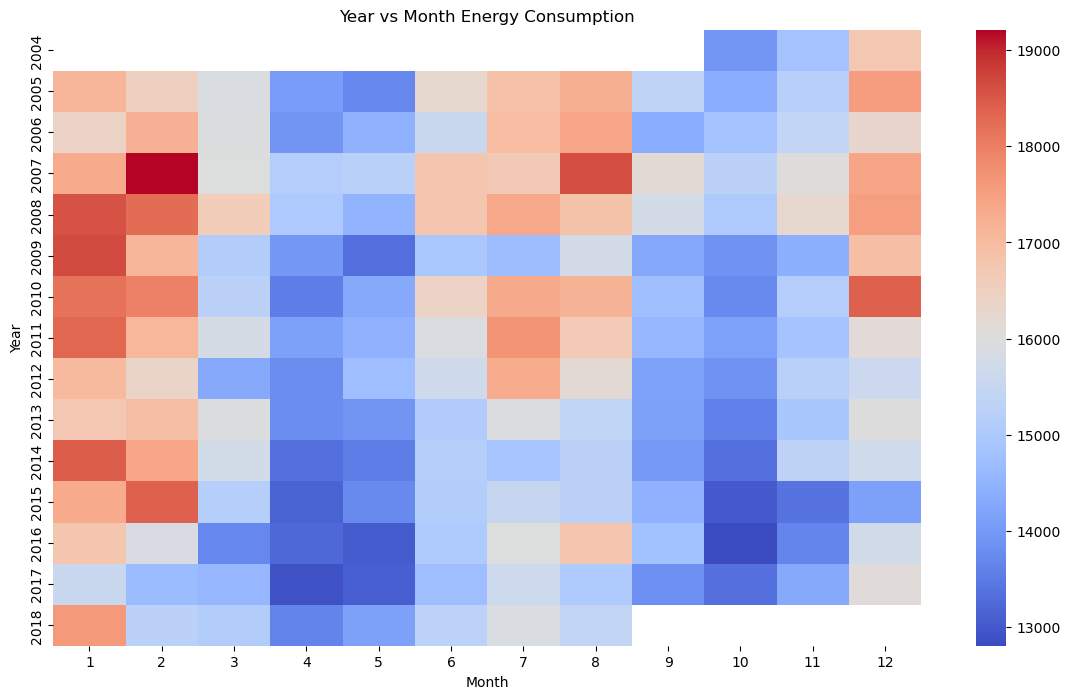

In [27]:
pivot_year_month = df.pivot_table(
    values='AEP_MW',
    index='Year',
    columns='Month',
    aggfunc='mean')
plt.figure(figsize=(14,8))
sns.heatmap(
    pivot_year_month,
    cmap='coolwarm')
plt.title('Year vs Month Energy Consumption')
plt.show()

- Electricity use is high in winter and summer, and lower in spring and autumn.
- The heatmap shows that January, February, July, August, and December often have higher electricity use. The middle months like April, May, September, and October are usually lower.
- Over time, electricity use seems to be slowly going down, so companies should track whether this continues.

### 3. Month × Hour Heatmap

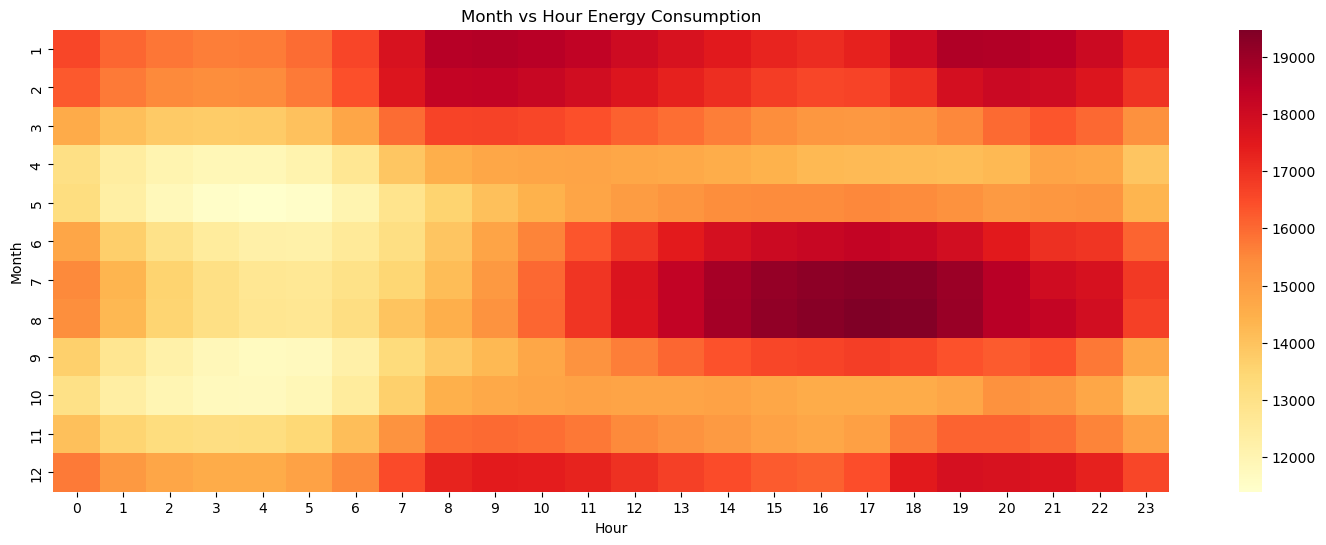

In [17]:
pivot = df.pivot_table(
    values='AEP_MW',
    index='Month',columns='Hour',aggfunc='mean')
plt.figure(figsize=(18,6))
sns.heatmap(pivot,cmap='YlOrRd')
plt.title('Month vs Hour Energy Consumption')
plt.show()

- This graph shows how electricity use changes by both month and hour of the day.
- The darkest red areas (highest use) appear during July–August afternoons and evenings.
- Electricity use is lowest during the early morning hours (around 2–5 AM) across almost all months.
- Winter months (January, February, December) also show high electricity use, especially during daytime and evening hours.

#  **Executive Summary**

- The data is slightly right-skewed, meaning extreme high values appear occasionally.
- The energy usage values are mostly concentrated in a stable range, with a few high-demand spikes.
- These spikes likely represent periods of high heating/cooling load or unusually active usage.
- This makes the dataset very useful for forecasting peak demand and planning grid capacity.

### **Overall Main Insights & Core Findings**
- Electricity demand is highest during weekday daytime and evening hours and lowest during the early morning.
- Winter and summer months consistently show higher energy consumption than spring and autumn.
- Weekdays consume more electricity than weekends due to increased commercial and industrial activity.
- While overall demand fluctuates across years, the daily and seasonal consumption patterns remain consistent.

## **Key Patterns Observed**
- Hourly Pattern :  Demand is lowest overnight, rises in the morning, and peaks during evening hours.
- Weekly Pattern : Weekdays show higher consumption compared to weekends.
- Seasonal Pattern : Energy usage increases during extreme weather months (winter and summer).
- Yearly Pattern : Long-term demand levels vary, but consumption behavior remains largely unchanged.

### **Strategic Recommendations for Utility Companies**
1. Strengthen Peak Demand Management: Plan extra power for weekday evenings. Demand is highest when people are active at home and in businesses, so this is the most critical time for supply planning.
2. Improve Seasonal Energy Planning: Prepare for summer and winter peaks. Electricity use rises in very hot and very cold months, so utilities should keep backup capacity ready for these seasons.
3. Expand Demand Forecasting Capabilities: Use lower-demand hours for maintenance. Improve operational efficiency by predicting peak-load periods in advance and reducing supply-demand imbalances.
4. Promote Energy Efficiency : Implement energy efficiency initiatives to reduce peak demand pressure and lower operational costs.